# 机器翻译数据集


In [1]:
import torch
import os
import util

下载预处理数据集


In [4]:
def read_data_nmt():
    """加载“英语-法语”数据集"""
    data_dir = util.data.download_extract('fra-eng')
    with open(os.path.join(data_dir, 'fra.txt'), 'r', encoding='utf-8') as f:
        return f.read()

raw_text = read_data_nmt()
print(raw_text[:75])

Go.	Va !
Hi.	Salut !
Run!	Cours !
Run!	Courez !
Who?	Qui ?
Wow!	Ça alors !



预处理并拆分


In [9]:
def preprocess_nmt(text):
    """预处理“英语-法语”数据集"""
    def no_space(char, prev_char):
        """判断是否需要在两个字符之间添加空格"""
        return char in set(',.!?') and prev_char != ' '
    text = text.replace('\u202f', ' ').replace('\xa0', ' ').lower() # 将文本转换为小写，并替换特殊空格
    out = [' ' + char if i > 0 and no_space(char, text[i - 1]) else char for i, char in enumerate(text)] # 在标点符号前添加空格
    return ''.join(out)

def tokenize_nmt(text, num_examples=None):
    """将“英语-法语”数据集拆分为英语和法语的句子对"""
    source, target = [], []
    for i, line in enumerate(text.split('\n')):
        if num_examples and i > num_examples:
            break
        parts = line.split('\t')
        if len(parts) == 2:
            source.append(parts[0].split(' '))
            target.append(parts[1].split(' '))
    return source, target

text = preprocess_nmt(raw_text)
source, target = tokenize_nmt(text)
source[:5], target[:5]

([['go', '.'], ['hi', '.'], ['run', '!'], ['run', '!'], ['who', '?']],
 [['va', '!'], ['salut', '!'], ['cours', '!'], ['courez', '!'], ['qui', '?']])

绘制 token 频率直方图


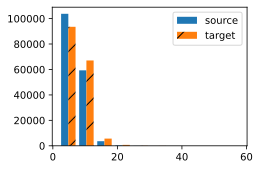

In [11]:
util.set_figsize()
_, _, patches = util.plt.hist([[len(l) for l in source], [len(l) for l in target]], label=['source', 'target'])
for patch in patches[1].patches:
    patch.set_hatch('/')
util.plt.legend(loc='upper right')

词汇表


In [13]:
src_vocab = util.Vocab(source, min_freq=2, reserved_tokens=['<pad>', '<bos>', '<eos>'])

len(src_vocab), src_vocab.token_freqs[:5]

(10012,
 [('.', 139392), ('i', 45611), ('you', 43192), ('to', 36718), ('the', 33263)])

序列样本有固定长度，截断或填充文本序列


In [14]:
def truncate_pad(line, num_steps, padding_token):
    """截断或填充文本序列"""
    if len(line) > num_steps:
        return line[:num_steps]  # 截断
    return line + [padding_token] * (num_steps - len(line))  # 填充

truncate_pad(src_vocab[source[0]], 10, src_vocab['<pad>'])

[47, 4, 1, 1, 1, 1, 1, 1, 1, 1]

转换成小批量


In [15]:
def build_array_nmt(lines, vocab, num_steps):
    """返回小批量"""
    lines = [vocab[l] for l in lines]
    lines = [l + [vocab['<eos>']] for l in lines]  # 添加 <eos> 结束标记
    array = torch.tensor([truncate_pad(l, num_steps, vocab['<pad>']) for l in lines])
    valid_len = (array != vocab['<pad>']).type(torch.int32).sum(1)  # 计算有效长度
    return array, valid_len

模型训练


In [16]:
def load_data_nmt(batch_size, num_steps, num_examples=600):
    """返回“英语-法语”数据集的迭代器和词表"""
    text = preprocess_nmt(read_data_nmt())
    source, target = tokenize_nmt(text, num_examples)
    src_vocab = util.Vocab(source, min_freq=2, reserved_tokens=['<pad>', '<bos>', '<eos>'])
    tgt_vocab = util.Vocab(target, min_freq=2, reserved_tokens=['<pad>', '<bos>', '<eos>'])
    src_array, src_valid_len = build_array_nmt(source, src_vocab, num_steps)
    tgt_array, tgt_valid_len = build_array_nmt(target, tgt_vocab, num_steps)
    data_arrays = (src_array, src_valid_len, tgt_array, tgt_valid_len)
    data_iter = util.data.load_array(data_arrays, batch_size)
    return data_iter, src_vocab, tgt_vocab

读出一个小批量数据


In [18]:
train_iter, src_vocab, tgt_vocab = load_data_nmt(batch_size=2, num_steps=8)
for X, X_valid_len, Y, Y_valid_len in train_iter:
    print('X:', X.type(torch.int32))
    print('X有效长度:', X_valid_len)
    print('Y:', Y.type(torch.int32))
    print('Y有效长度:', Y_valid_len)
    break

X: tensor([[  7,   0,   4,   3,   1,   1,   1,   1],
        [183,  10,  11,   3,   1,   1,   1,   1]], dtype=torch.int32)
X有效长度: tensor([4, 4])
Y: tensor([[  6,   7,   0,   4,   3,   1,   1,   1],
        [197,   8,   0,   9,   3,   1,   1,   1]], dtype=torch.int32)
Y有效长度: tensor([5, 5])
